**SVM**

SVM is a binary classification machine learning model with two classes- $+1$ and $-1$.

The goal of SVM is to find a hyperplane separating the classes as best as possible.

in 2D, this is just finding a line $a+bx+cy=0$. This line splits $\mathbb{R}^2$ into two regions: on one side, $a+bx+cy>0$ and on the other $a+bx+cy<0$.

The method makes predictions where the prediction for point $(x,y)$ is equal to the sign of the function $f(x,y)=a+bx+cy$.

We want to penalize incorrect predictions *and* points inside the band $-1\leq f(x,y) \leq 1$.

Suppose we are given data points $(c_1,[x_1,y_1]),\ldots, (c_n,[x_m,y_n])$.

we will minimize the following function, 'loss' :

$$\text{loss} = \frac{1}{2} \sum_{i=1}^m (\max\{0,1-c_i(a+bx_i+cy_i)\})^2$$

we now compute the gradient of loss:

$\partial\text{loss}/\partial a = \sum_{i=1}^m \max\{0,1-c_i(a+bx_i+cy_i)\}\cdot\{0\text{ or 1}\}(-c_i)$ depending on if $1-c_1(a+bx_1+cy_1)$ is less than or greater than zero.

We rewrite as $-\sum_{i=1}^mc_i\max\{0,1-c_i(a+bx_i+cy_i)\}$

we now have $\partial\text{loss}/\partial b = -\sum_{i=1}^mc_ix_i\max\{0,1-c_i(a+bx_i+cy_i)\}$

and $\partial\text{loss}/\partial c = -\sum_{i=1}^mc_iy_i\max\{0,1-c_i(a+bx_i+cy_i)\}$

Now, $\nabla\text{loss}=-\sum_{i=1}^mc_i\max\{0,1-c_i(a+bx_i+cy_i)\}[1,x_i.y_i]^T = -[1|X|Y]^T[c_i\max\{0,1-c_i(a+bx_i+cy_i)\}]$
***

In [1]:
import numpy as np
import matplotlib.pyplot as plt

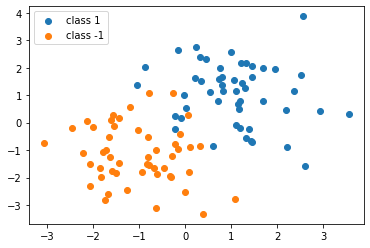

In [6]:
# example 1
m = 50
x = np.zeros(2*m)
y = np.zeros(2*m)
c = np.zeros(2*m)

#class 1
x[0:m] = np.random.randn(m)+1
y[0:m] = np.random.randn(m)+1
c[0:m] = 1

#class 2
x[m:2*m] = np.random.randn(m)-1
y[m:2*m] = np.random.randn(m)-1
c[m:2*m] = -1

plt.scatter(x[c==1],y[c==1], label = 'class 1')
plt.scatter(x[c==-1],y[c==-1], label = 'class -1')
plt.legend()

In [7]:
A = np.ones((2*m,3))
A[:,1] = x
A[:,2] = y

In [9]:
def loss(c,A,coeffs):
    return 0.5*np.sum(np.maximum(0,1-c*A.dot(coeffs))**2)

In [23]:
# gradient descent
coeffs = np.random.randn(3)
n_epochs = 25
s = 0.01 #learning rate
losses = [loss(c,A,coeffs)]

for epoch in range(n_epochs):
    gradient = -A.T.dot(c*np.maximum(0,1-c*A.dot(coeffs)))
    coeffs = coeffs -s*gradient
    losses.append(loss(c,A,coeffs))

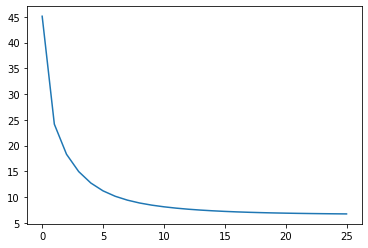

In [24]:
plt.plot(losses)

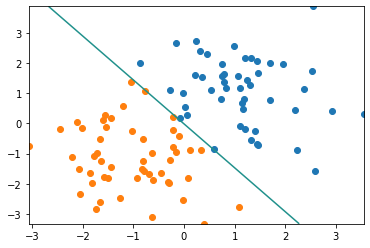

In [28]:
# predictions
p =  A.dot(coeffs)
plt.scatter(x[p>=0],y[p>=0], label = 'predict class 1')
plt.scatter(x[p<0],y[p<0], label = 'predict class -1')

m_plot = 200
x_plot = np.linspace(np.min(x),np.max(x),m_plot)
y_plot = np.linspace(np.min(y),np.max(y),m_plot)

X,Y = np.meshgrid(x_plot,y_plot)

Z = coeffs[0]+coeffs[1]*X+coeffs[2]*Y

plt.contour(X,Y,Z,levels = 0)

# line

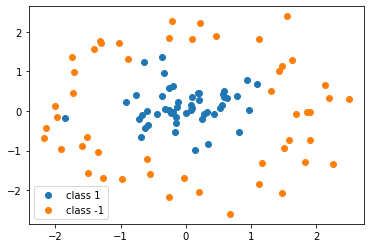

In [31]:
# example 2

# example 1
m = 50
x = np.zeros(2*m)
y = np.zeros(2*m)
c = np.zeros(2*m)

#class 1
x[0:m] = 0.5*np.random.randn(m)
y[0:m] = 0.5*np.random.randn(m)
c[0:m] = 1

#class 2
theta = np.linspace(0,2*np.pi,m)
x[m:2*m] = 2*np.cos(theta) + 0.3*np.random.randn(m)
y[m:2*m] = 2*np.sin(theta) + 0.3*np.random.randn(m)
c[m:2*m] = -1

plt.scatter(x[c==1],y[c==1], label = 'class 1')
plt.scatter(x[c==-1],y[c==-1], label = 'class -1')
plt.legend()

In [32]:
A = np.ones((2*m,6))
A[:,1] = x
A[:,2] = y
A[:,3] = x**2
A[:,4] = y**2
A[:,5] = x*y

In [37]:
# gradient descent
coeffs = np.random.randn(6)
n_epochs = 30
s = 0.01 #learning rate
losses = [loss(c,A,coeffs)]

for epoch in range(n_epochs):
    gradient = -A.T.dot(c*np.maximum(0,1-c*A.dot(coeffs)))
    coeffs = coeffs -s*gradient
    losses.append(loss(c,A,coeffs))

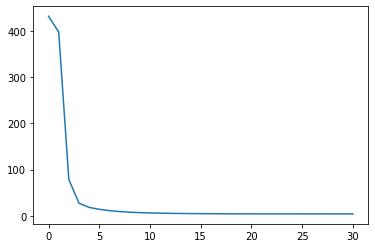

In [38]:
plt.plot(losses)

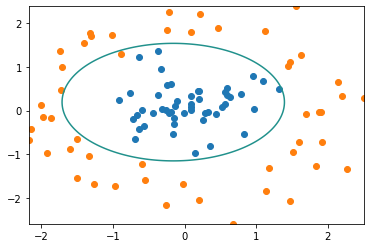

In [40]:
# predictions
p =  A.dot(coeffs)
plt.scatter(x[p>=0],y[p>=0], label = 'predict class 1')
plt.scatter(x[p<0],y[p<0], label = 'predict class -1')

m_plot = 200
x_plot = np.linspace(np.min(x),np.max(x),m_plot)
y_plot = np.linspace(np.min(y),np.max(y),m_plot)

X,Y = np.meshgrid(x_plot,y_plot)

Z = coeffs[0]+coeffs[1]*X+coeffs[2]*Y +coeffs[3]*X**2+coeffs[4]*Y**2+coeffs[5]*Y*Y

plt.contour(X,Y,Z,levels = 0)